In [1]:
# Tiny Temporal Graph Transformer (TGT) for Power-Flow Forecasting on IEEE-14 (Toy)

# What this notebook does:
# 1) Build an IEEE-14-like topology (20 branches, unit reactances)
# 2) Generate synthetic time-series loads
# 3) Compute "true" line flows via DC power flow
# 4) Train a tiny TGT to map past loads -> next-step line flows

import math, numpy as np, numpy.linalg as LA, networkx as nx, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [2]:
# Approximate IEEE-14 edges (20 branches), undirected, unit reactance
edges = [
    (1,2),(1,5),
    (2,3),(2,4),(2,5),
    (3,4),
    (4,5),(4,7),(4,9),
    (5,6),
    (6,11),(6,12),(6,13),
    (7,8),(7,9),
    (9,10),(9,14),
    (10,11),
    (12,13),
    (13,14)
]

G = nx.Graph(); G.add_edges_from(edges)
nodes = sorted(G.nodes()); n=len(nodes)
node_index = {v:i for i,v in enumerate(nodes)}
edge_index = [(node_index[u], node_index[v]) for (u,v) in G.edges()]
m = len(edge_index)
print(f"n={n}, m={m}")

def dc_pf_flows(net_injection):
    """DC PF with unit reactance; returns line flows (i->j) in edge_index order."""
    B = np.zeros((n,n))
    for (i,j) in edge_index:
        B[i,i]+=1; B[j,j]+=1; B[i,j]-=1; B[j,i]-=1
    slack=0
    keep=[k for k in range(n) if k!=slack]
    P = net_injection.copy()
    P[slack] = -np.sum(P[keep])
    theta_red = LA.solve(B[np.ix_(keep,keep)], P[keep])
    theta = np.zeros(n); theta[keep]=theta_red
    return np.array([(theta[i]-theta[j]) for (i,j) in edge_index])


n=14, m=20


In [3]:
# Synthesize time-series loads, create (X, Y) pairs:
# X: (lookback L) loads per node, Y: next-step line flows
# Look back is 12 - that is why 469+118+12=599
T_total = 600
rng = np.random.default_rng(7)
base = rng.uniform(0.2, 1.0, size=(n,))
amp  = rng.uniform(0.05,0.2, size=(n,))

loads, flows = [], []
for t in range(T_total):
    daily = np.sin(2*np.pi*(t%96)/96.0)  # slow cycle
    fast  = np.sin(2*np.pi*(t%24)/24.0)  # faster cycle
    eps   = rng.normal(0,0.02,size=(n,))
    l = base + amp*(0.6*daily + 0.4*fast) + eps
    loads.append(l)
    flows.append(dc_pf_flows(-l))  # injections = -loads

loads = np.stack(loads)   # (T, n)
flows = np.stack(flows)   # (T, m)

L = 12  # lookback
X, Y = [], []
for t in range(L, T_total-1):
    X.append(loads[t-L:t])   # (L, n)
    Y.append(flows[t])       # (m,)
X = np.stack(X)  # (N, L, n)
Y = np.stack(Y)  # (N, m)

split = int(0.8*len(X))
Xtr, Ytr = X[:split], Y[:split]
Xva, Yva = X[split:], Y[split:]
Xtr.shape, Ytr.shape, Xva.shape, Yva.shape

((469, 12, 14), (469, 20), (118, 12, 14), (118, 20))

In [4]:
flows[0]

array([3.74446977, 3.94935777, 1.13649679, 1.48304775, 0.20488801,
       1.27815975, 2.45552339, 0.34655096, 1.26780334, 1.46934442,
       0.84083204, 0.20154108, 0.44094822, 0.39293218, 0.58184147,
       0.47050745, 0.52050845, 0.15108754, 0.050001  , 0.1644045 ])

In [5]:
# Adjacency mask (neighbors + self)
A = np.zeros((n,n), dtype=bool)
for (i,j) in edge_index:
    A[i,j]=True; A[j,i]=True
for i in range(n): A[i,i]=True
A_mask = torch.from_numpy(A).to(device)

class SpatialAttention(nn.Module):
    def __init__(self, d_model=64, n_heads=4):
        super().__init__(); self.h=n_heads; self.dk=d_model//n_heads
        self.q=nn.Linear(d_model,d_model); self.k=nn.Linear(d_model,d_model); self.v=nn.Linear(d_model,d_model); self.o=nn.Linear(d_model,d_model)
    def forward(self, x, mask):
        # x: (B, N, D)
        B,N,D = x.shape; H=self.h; dk=self.dk
        q=self.q(x).view(B,N,H,dk).transpose(1,2)
        k=self.k(x).view(B,N,H,dk).transpose(1,2)
        v=self.v(x).view(B,N,H,dk).transpose(1,2)
        s=(q@k.transpose(-2,-1))/math.sqrt(dk)
        m = mask.unsqueeze(0).unsqueeze(0).expand(B,H,N,N)
        s = s.masked_fill(~m, float('-inf'))
        a = torch.softmax(s, dim=-1)
        out = a@v
        out = out.transpose(1,2).contiguous().view(B,N,D)
        return self.o(out)

class TemporalBlock(nn.Module):
    def __init__(self, d_model=64, n_heads=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.ln1 = nn.LayerNorm(d_model)
        self.ff  = nn.Sequential(nn.Linear(d_model, 4*d_model), nn.GELU(), nn.Linear(4*d_model, d_model))
        self.ln2 = nn.LayerNorm(d_model)
    def forward(self, x):
        # x: (B, T, D)
        y,_ = self.attn(x,x,x); x=self.ln1(x+y)
        y = self.ff(x); x=self.ln2(x+y); return x

class TinyTGT(nn.Module):
    def __init__(self, n_nodes, n_edges, d_model=64, n_heads=4, n_temporal_layers=2):
        super().__init__(); self.n_nodes=n_nodes; self.n_edges=n_edges
        self.enc = nn.Linear(1, d_model)        # encode scalar load -> embedding
        self.spat = SpatialAttention(d_model, n_heads)
        self.temporal = nn.ModuleList([TemporalBlock(d_model, n_heads) for _ in range(n_temporal_layers)])
        self.edge_mlp = nn.Sequential(nn.Linear(2*d_model, 2*d_model), nn.GELU(), nn.Linear(2*d_model,1))
        src = torch.tensor([i for (i,_) in edge_index], device=device)
        dst = torch.tensor([j for (_,j) in edge_index], device=device)
        self.register_buffer('src', src); self.register_buffer('dst', dst)
    def forward(self, loads_seq, mask):
        # loads_seq: (B, T, N)
        B,T,N = loads_seq.shape
        x = self.enc(loads_seq.reshape(B*T*N,1)).view(B,T,N,-1)   # (B,T,N,D)
        # Spatial attention per time
        x_ = self.spat(x.view(B*T, N, -1), mask).view(B, T, N, -1)
        # Temporal attention per node
        x_bn = x_.permute(0,2,1,3).contiguous().view(B*N, T, -1)
        for layer in self.temporal:
            x_bn = layer(x_bn)
        hT = x_bn[:,-1,:].view(B, N, -1)
        # Edge readout
        h_src = hT[:, self.src, :]; h_dst = hT[:, self.dst, :]
        return self.edge_mlp(torch.cat([h_src, h_dst], dim=-1)).squeeze(-1)  # (B, m)

model = TinyTGT(n_nodes=n, n_edges=m, d_model=64, n_heads=4).to(device)
sum(p.numel() for p in model.parameters())


133377

In [6]:
def to_tensors(X, Y):
    return torch.from_numpy(X).float().to(device), torch.from_numpy(Y).float().to(device)

Xtr_t, Ytr_t = to_tensors(Xtr, Ytr)
Xva_t, Yva_t = to_tensors(Xva, Yva)

opt = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
batch_size = 128
epochs = 100  # increase for better accuracy

def minibatches(X, Y, bs):
    idx = torch.randperm(X.shape[0])
    for i in range(0, len(idx), bs):
        j = idx[i:i+bs]
        yield X[j], Y[j]

for ep in range(1, epochs+1):
    model.train(); train_loss=0.0
    for xb, yb in minibatches(Xtr_t, Ytr_t, batch_size):
        opt.zero_grad(set_to_none=True)
        yhat = model(xb, A_mask)
        loss = loss_fn(yhat, yb)
        loss.backward(); opt.step()
        train_loss += loss.item()*xb.size(0)
    train_loss /= Xtr_t.size(0)
    model.eval()
    with torch.no_grad():
        val_loss = loss_fn(model(Xva_t, A_mask), Yva_t).item()
    print(f"Epoch {ep}: train MSE={train_loss:.6f} | val MSE={val_loss:.6f}")

Epoch 1: train MSE=1.601417 | val MSE=1.296454
Epoch 2: train MSE=1.280076 | val MSE=1.278472
Epoch 3: train MSE=1.256390 | val MSE=1.262279
Epoch 4: train MSE=1.230140 | val MSE=1.255660
Epoch 5: train MSE=1.203301 | val MSE=1.221064
Epoch 6: train MSE=1.162131 | val MSE=1.145012
Epoch 7: train MSE=1.083233 | val MSE=1.050831
Epoch 8: train MSE=1.023077 | val MSE=1.041061
Epoch 9: train MSE=1.002543 | val MSE=0.998626
Epoch 10: train MSE=0.962612 | val MSE=0.977511
Epoch 11: train MSE=0.944221 | val MSE=0.945349
Epoch 12: train MSE=0.911937 | val MSE=0.928841
Epoch 13: train MSE=0.892016 | val MSE=0.884219
Epoch 14: train MSE=0.859641 | val MSE=0.872142
Epoch 15: train MSE=0.838557 | val MSE=0.866197
Epoch 16: train MSE=0.845570 | val MSE=0.878345
Epoch 17: train MSE=0.826721 | val MSE=0.785968
Epoch 18: train MSE=0.806762 | val MSE=0.794756
Epoch 19: train MSE=0.813112 | val MSE=0.762827
Epoch 20: train MSE=0.780396 | val MSE=0.781516
Epoch 21: train MSE=0.794146 | val MSE=0.749577
E

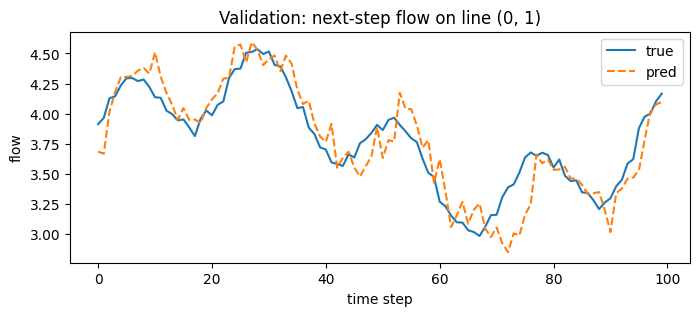

In [7]:
with torch.no_grad():
    pred = model(Xva_t, A_mask).cpu().numpy()

line_id = 0  # pick one line to visualize
true_line = Yva[:, line_id]
pred_line = pred[:, line_id]

plt.figure(figsize=(8,3))
plt.plot(true_line[:100], label='true')
plt.plot(pred_line[:100], label='pred', linestyle='--')
plt.title(f'Validation: next-step flow on line {edge_index[line_id]}')
plt.xlabel('time step'); plt.ylabel('flow'); plt.legend(); plt.show()

In [8]:
print(model)

TinyTGT(
  (enc): Linear(in_features=1, out_features=64, bias=True)
  (spat): SpatialAttention(
    (q): Linear(in_features=64, out_features=64, bias=True)
    (k): Linear(in_features=64, out_features=64, bias=True)
    (v): Linear(in_features=64, out_features=64, bias=True)
    (o): Linear(in_features=64, out_features=64, bias=True)
  )
  (temporal): ModuleList(
    (0-1): 2 x TemporalBlock(
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
      )
      (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (ff): Sequential(
        (0): Linear(in_features=64, out_features=256, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=256, out_features=64, bias=True)
      )
      (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
  )
  (edge_mlp): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): GELU(approximate='none')
  